In [1]:
import psycopg2
import json
from decimal import Decimal

def fetch_data_from_postgres(query, db_config):
    """
    Fetches data from PostgreSQL and returns it in JSON format.
    Retains PostgreSQL date, time, and datetime as string without conversion.
    """
    conn = None
    result = ""
    
    try:
        # Connect to PostgreSQL
        conn = psycopg2.connect(**db_config)
        cur = conn.cursor()

        # Execute query
        print(f"\n🔎 Executing query:\n{query}\n")
        cur.execute(query)
        rows = cur.fetchall()

        # Fetch column names
        col_names = [desc[0] for desc in cur.description]

        # Convert rows to list of dictionaries
        data = []
        for row in rows:
            record = {}
            for col, value in zip(col_names, row):
                if isinstance(value, Decimal):
                    record[col] = float(value)  # Convert Decimal to float
                else:
                    record[col] = str(value)  # Keep all other types as string
            data.append(record)

        # Convert data to JSON
        result = json.dumps(data, indent=4)

    except psycopg2.Error as e:
        print(f"❌ Error: {e}")
        result = json.dumps({"error": str(e)})
    
    finally:
        if conn:
            conn.close()

    return result


# PostgreSQL connection config
db_config = {
     "host": "localhost",            # or your DB host
    "database": "postgres",
    "user": "postgres",
    "password": "root",
    "port": "5432"                   # default PostgreSQL port
}


# ✅ Take SQL query from the user
query = input("\n🛠️ Enter your SQL query: ")

# Fetch the data
json_result = fetch_data_from_postgres(query, db_config)

# Display the JSON result
print("\n📊 Query Result in JSON format:")
print(json_result)



🔎 Executing query:
select * from machine_data


📊 Query Result in JSON format:
[
    {
        "date": "2025-03-21",
        "start_timestamp": "1742524632977",
        "end_timestamp": "1742531008589",
        "tenantid": "9",
        "v2tenant": "b1d5e29f-3c3d-4649-849a-13e0e9684bee",
        "org_id": "d94b2968-0029-4e7e-b676-e869aa4c45f9",
        "unit_id": "76ca1188-ef90-4eaa-91f1-7149ea82bb0f",
        "department_id": "2295363e-9921-49fd-be44-3009d6b32331",
        "machineid": "CNC003",
        "edgeid": "e420003",
        "shiftid": "1",
        "part_id": "(ENCODER COUPLING_2ND)",
        "piece_number": "106",
        "pieces_produced_life": "5974",
        "actual_cycletime": 24976.0,
        "time_between_jobs": 0.0,
        "average_cycletime": "143714.28",
        "cutting_time": 4853495.0,
        "local_time": "08:07:12"
    },
    {
        "date": "2025-03-21",
        "start_timestamp": "1742531010805",
        "end_timestamp": "1742531096760",
        "tenantid":

In [8]:
import pandas as pd
import numpy as np
import json
from datetime import datetime


# ✅ Load JSON into a DataFrame
data = json.loads(json_result)
df = pd.DataFrame(data)

# ✅ Handle NaN values properly
# df.replace("NaN", np.nan, inplace=True)

# ✅ Dynamic type conversions based on column existence
def dynamic_type_conversion(df):
    df.replace("NaN", np.nan, inplace=True)
    """
    Dynamically converts data types in a DataFrame based on column presence
    and recommended Pandas data types.
    """
    
    # ✅ Convert timestamps to datetime64[ns]
    if 'start_timestamp' in df.columns:
        df['start_timestamp'] = pd.to_datetime(df['start_timestamp'].astype(float) / 1000, unit='s')

    if 'end_timestamp' in df.columns:
        df['end_timestamp'] = pd.to_datetime(df['end_timestamp'].astype(float) / 1000, unit='s')

    # ✅ Convert date and local_time to datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    if 'local_time' in df.columns:
        # Convert local_time to datetime64[ns] for easier time-series plots
        df['local_time'] = pd.to_datetime(df['local_time'], format='%H:%M:%S', errors='coerce')

    # ✅ Convert numerical columns to int64 or float64
    int_cols = ['tenantid','piece_number', 'pieces_produced_life', 'shiftid']
    float_cols = ['actual_cycletime', 'time_between_jobs', 'average_cycletime', 'cutting_time']

    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    for col in float_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

    # ✅ Convert UUIDs and IDs to string or category
    cat_cols = ['tenantid','v2tenant', 'org_id', 'unit_id', 'department_id', 'machineid', 'edgeid', 'part_id','shiftid']

    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    return df
# ✅ Apply dynamic type conversion
df = dynamic_type_conversion(df)

# ✅ Check the final DataFrame and types
print(df.dtypes)
df.head()


date                    datetime64[ns]
start_timestamp         datetime64[ns]
end_timestamp           datetime64[ns]
tenantid                      category
v2tenant                      category
org_id                        category
unit_id                       category
department_id                 category
machineid                     category
edgeid                        category
shiftid                       category
part_id                       category
piece_number                     Int64
pieces_produced_life             Int64
actual_cycletime               float64
time_between_jobs              float64
average_cycletime              float64
cutting_time                   float64
local_time              datetime64[ns]
dtype: object


,date,start_timestamp,end_timestamp,tenantid,v2tenant,org_id,unit_id,department_id,machineid,edgeid,shiftid,part_id,piece_number,pieces_produced_life,actual_cycletime,time_between_jobs,average_cycletime,cutting_time,local_time
0,2025-03-21,2025-03-21 02:37:12.976999998,2025-03-21 04:23:28.588999987,9,b1d5e29f-3c3d-4649-849a-13e0e9684bee,d94b2968-0029-4e7e-b676-e869aa4c45f9,76ca1188-ef90-4eaa-91f1-7149ea82bb0f,2295363e-9921-49fd-be44-3009d6b32331,CNC003,e420003,1,(ENCODER COUPLING_2ND),106,5974,24976.0,0.0,143714.28,4853495.0,1900-01-01 08:07:12
1,2025-03-21,2025-03-21 04:23:30.805000067,2025-03-21 04:24:56.759999990,9,b1d5e29f-3c3d-4649-849a-13e0e9684bee,d94b2968-0029-4e7e-b676-e869aa4c45f9,76ca1188-ef90-4eaa-91f1-7149ea82bb0f,2295363e-9921-49fd-be44-3009d6b32331,CNC003,e420003,1,(ENCODER COUPLING_2ND),107,5975,23680.0,2216.0,143714.28,83714.0,1900-01-01 09:53:30
2,2025-03-21,2025-03-21 04:24:59.033999920,2025-03-21 04:33:47.206000090,9,b1d5e29f-3c3d-4649-849a-13e0e9684bee,d94b2968-0029-4e7e-b676-e869aa4c45f9,76ca1188-ef90-4eaa-91f1-7149ea82bb0f,2295363e-9921-49fd-be44-3009d6b32331,CNC003,e420003,1,(ENCODER COUPLING_2ND),108,5976,192464.0,2274.0,143714.28,525928.0,1900-01-01 09:54:59
3,2025-03-21,2025-03-21 04:33:49.453999996,2025-03-21 04:43:25.586999893,9,b1d5e29f-3c3d-4649-849a-13e0e9684bee,d94b2968-0029-4e7e-b676-e869aa4c45f9,76ca1188-ef90-4eaa-91f1-7149ea82bb0f,2295363e-9921-49fd-be44-3009d6b32331,CNC003,e420003,1,(ENCODER COUPLING_2ND),109,5977,191072.0,2248.0,143714.28,573893.0,1900-01-01 10:03:49
4,2025-03-21,2025-03-21 04:43:27.832000017,2025-03-21 04:47:36.142999887,9,b1d5e29f-3c3d-4649-849a-13e0e9684bee,d94b2968-0029-4e7e-b676-e869aa4c45f9,76ca1188-ef90-4eaa-91f1-7149ea82bb0f,2295363e-9921-49fd-be44-3009d6b32331,CNC003,e420003,1,(ENCODER COUPLING_2ND),110,5978,190784.0,2245.0,143714.28,246031.0,1900-01-01 10:13:27


## Latest Running

In [5]:
import plotly.express as px

def choose_plot(df):
    """
    Dynamically selects the best plot type based on the structure of the DataFrame.
    """
    num_cols = df.select_dtypes(include=['object','number']).columns.tolist()
    print(f"Numerical columns: {num_cols}")
    # Check for categorical columns
    cat_cols = df.select_dtypes(include=[ 'category']).columns.tolist()
    print(f"Categorical columns: {cat_cols}")
    # Check for datetime columns
    datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
    print(f"Datetime columns: {datetime_cols}")
    # object_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    
    if any(col in df.columns for col in ['date', 'timestamp', 'start_timestamp', 'end_timestamp', 'local_time']):
        # Determine the appropriate column for the x-axis
        time_col = next((col for col in ['date', 'timestamp', 'start_timestamp', 'end_timestamp', 'local_time'] if col in df.columns), None)
        # Time Series: Show trends over time
        return px.line(df, x=time_col, y=num_cols[0], title=f"Trend of {num_cols[0]} Over Time")

    elif len(num_cols) == 1 and len(cat_cols) == 0:
        # Single numerical column: Histogram or Box Plot
        return px.histogram(df, x=num_cols[0], title=f"Distribution of {num_cols[0]}")
    
    elif len(num_cols) == 2 and len(cat_cols) == 0:
        # Two numerical columns: Scatter plot for correlation analysis
        return px.scatter(df, x=num_cols[0], y=num_cols[1], title=f"{num_cols[0]} vs {num_cols[1]}")

    elif len(cat_cols) >= 1 and len(num_cols) >= 1:
        # Category vs Numeric: Bar chart or Violin plot
        return px.bar(df, x=cat_cols[0], y=num_cols[0], title=f"{num_cols[0]} by {cat_cols[0]}")
    
    elif len(cat_cols) == 2 and len(num_cols) == 1:
        return px.pie(df, names=cat_cols[0], values=num_cols[0], title=f"Distribution of {num_cols[0]} by {cat_cols[0]}")

    elif len(cat_cols) >= 3 and len(num_cols) == 0:
        # Multiple categorical columns: Sunburst chart for hierarchy visualization
        return px.sunburst(df, path=cat_cols[:2], values=num_cols[0] if num_cols else None, 
                           title="Hierarchical Distribution")

    elif len(num_cols) > 2:
        # If more than 2 numerical columns: Pairplot for correlation analysis
        if len(num_cols) >= 4:
            return px.scatter_matrix(df, dimensions=num_cols[:4], title="Pairwise Relationships")
        else:
            return px.scatter_matrix(df, dimensions=num_cols, title="Pairwise Relationships")

    else:
        # Default to Box plot if no clear pattern emerges
        if num_cols:
            return px.box(df, y=num_cols[0], title=f"Box Plot of {num_cols[0]}")
        else:
            return px.box(df, title="Box Plot")

# Example Usage
fig = choose_plot(df)
fig.show()
df

Numerical columns: ['total_pieces']
Categorical columns: ['machineid']
Datetime columns: []


,machineid,total_pieces
0,CNC004,189788930
1,CNC003,1687995


In [8]:
import plotly.express as px


In [9]:
fig = px.bar(df, x="machineid", y="total_pieces", 
             title="Total Pieces Produced by CNC003", 
             labels={"machineid": "Machine ID", "total_pieces": "Total Pieces Produced"})
fig.show()


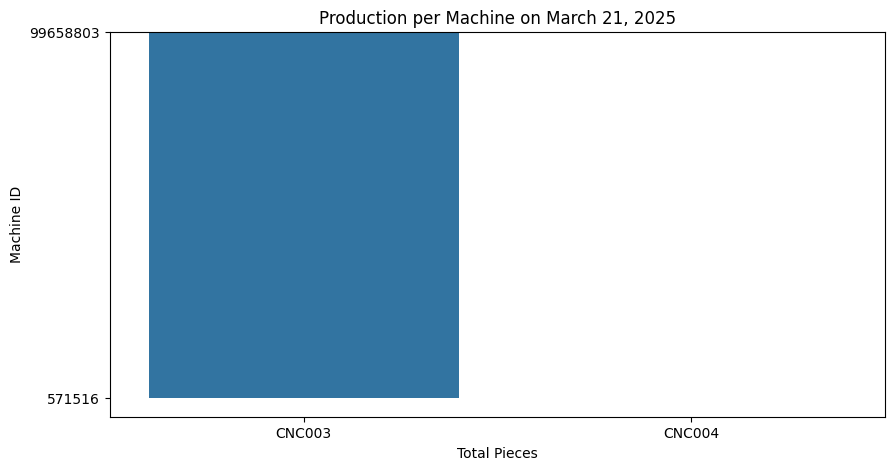

,machineid,total_pieces
0,CNC004,99658803
1,CNC003,571516


In [17]:
# Machine that produced the most pieces on a specific date
plt.figure(figsize=(10,5))
sns.barplot(x=df['machineid'], y=df['total_pieces'])
plt.xlabel('Total Pieces')
plt.ylabel('Machine ID')
plt.title('Production per Machine on March 21, 2025')
plt.show()
df

In [33]:
fig = px.histogram(df, x="time_between_jobs", nbins=20,
                   title="Distribution of Downtime Between Jobs",
                   labels={"time_between_jobs": "Downtime (ms)"})
fig.show()
df

,time_between_jobs
0,889804.0
1,889581.0
2,904099.0
3,840801.0
4,905153.0
5,839337.0
6,879577.0


In [37]:
fig = px.histogram(df, x="machineid",
                   title="Machines Used in Production",
                   labels={"machineid": "Machine ID"},
                   text_auto=True)
fig.show()
df

,machineid
0,CNC004
1,CNC003


In [48]:
import plotly.express as px

fig = px.bar(df, x="machineid", y="total_cycle_time",
             title="Total Cycle Time per Machine on March 21, 2025",
             labels={"machineid": "Machine ID", "total_cycle_time": "Total Cycle Time"})
fig.show()


In [52]:
# Shift with the highest production
fig = px.pie(df, names="shiftid", values="total_pieces",
             title="Production Distribution by Shift on March 21, 2025")
fig.show()
df

,shiftid,total_pieces
0,1,52342562
1,2,47887757


In [55]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(z=df.isnull().astype(int),
                                colorscale="Viridis"))
fig.update_layout(title="Missing Values in Machine Data", xaxis_title="Columns")
fig.show()


In [62]:
fig = px.bar(df, x='shiftid', y='average_cycletime', 
             error_y='cycle_variance', 
             title='Average Cycle Time per Shift',
             labels={'shiftid': 'Shift', 'average_cycletime': 'Avg Cycle Time'},
             color='shiftid')

fig.show()
df

,shiftid,average_cycletime,cycle_variance
0,2,90231.877996,69829.043101
1,1,77291.652830,62911.259040


In [71]:
import plotly.express as px
import pandas as pd
from datetime import datetime

def choose_plot(df, max_categories=10):
    """
    Dynamically selects the best plot type based on DataFrame structure and content.
    Handles edge cases and uses visualization best practices.
    """
    # Helper function for proportion check
    def is_proportional(series, threshold=0.02):
        total = series.sum()
        return abs(total - 100) < threshold or abs(total - 1) < threshold

    # Get column types
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
    
    # Check for time series first using actual datetime columns
    if datetime_cols:
        time_col = datetime_cols[0]
        if num_cols:
            return px.line(df, x=time_col, y=num_cols[0], 
                          title=f"Time Series: {num_cols[0]} over Time")
        return px.scatter(df, x=time_col, title=f"Timeline of {time_col}")

    # Check for proportional data (pie chart scenario)
    if len(num_cols) == 1 and len(cat_cols) == 1:
        if is_proportional(df[num_cols[0]]):
            return px.pie(df, names=cat_cols[0], values=num_cols[0], 
                         title=f"Proportion of {cat_cols[0]}")

    # Single numerical column
    if len(num_cols) == 1 and not cat_cols:
        if df[num_cols[0]].nunique() > max_categories:
            return px.histogram(df, x=num_cols[0], 
                               title=f"Distribution of {num_cols[0]}")
        return px.box(df, y=num_cols[0], 
                    title=f"Box Plot of {num_cols[0]}")

    # Categorical vs Numerical analysis
    if cat_cols and num_cols:
        primary_cat = cat_cols[0]
        primary_num = num_cols[0]
        
        # Choose between bar plot and box plot based on cardinality
        if df[primary_cat].nunique() <= max_categories:
            if df[primary_num].nunique() == 1:
                return px.bar(df, x=primary_cat, y=primary_num,
                            title=f"{primary_num} by {primary_cat}")
            return px.box(df, x=primary_cat, y=primary_num,
                        title=f"Distribution of {primary_num} by {primary_cat}")
        return px.scatter(df, x=primary_cat, y=primary_num,
                        title=f"{primary_num} vs {primary_cat}")

    # Two numerical columns
    if len(num_cols) == 2:
        return px.scatter(df, x=num_cols[0], y=num_cols[1], 
                        title=f"{num_cols[0]} vs {num_cols[1]} Correlation")

    # Multiple numerical columns
    if len(num_cols) > 2:
        return px.scatter_matrix(df, dimensions=num_cols[:4], 
                               title="Pairwise Numerical Relationships")

    # Hierarchical categorical data
    if len(cat_cols) >= 2:
        try:  # Sunburst requires at least root + one level
            return px.sunburst(df, path=cat_cols[:3], 
                             title="Hierarchical Structure")
        except:
            return px.treemap(df, path=cat_cols[:3], 
                            title="Hierarchical Structure")

    # Fallback for unhandled cases
    return px.scatter(df, title="Default Scatter Plot Visualization")

# Example usage
if __name__ == "__main__":
    # Test with different dataframe structures
    sales_data = df
    
    customer_data = pd.DataFrame({
        'Country': ['USA', 'Canada', 'Mexico']*10,
        'Satisfaction': np.random.randint(1, 5, 30),
        'Spending': np.random.normal(100, 20, 30)
    })
    
    choose_plot(sales_data).show()
   